# 📊 Alternative Credit Scoring and Default Risk Prediction for Gig Workers
### Assessing Financial Risk in the Modern Gig Economy

---

## 🔷 1. TITLE & PROBLEM STATEMENT

### Context
The global economy is witnessing a paradigm shift with the rapid growth of the **Gig Economy**. Millions of workers are now engaged in freelance, delivery, and service-based roles through platforms like Uber, Swiggy, Fiverr, and Upwork. However, these workers often face a significant hurdle: **Financial Exclusion**.

### The Problem
Traditional banking systems rely heavily on stable monthly salaries, credit history (CIBIL/FICO), and formal employment documentation to assess creditworthiness. Gig workers, characterized by volatile earnings and non-traditional work patterns, are frequently flagged as "high-risk" or "thin-file" by legacy models, despite being high earners or disciplined professionals.

### The Solution: Alternative Credit Scoring
This project aims to bridge this gap by developing an **Alternative Credit Scoring System**. Instead of relying on traditional banking signals, we leverage **Platform-Integrated Data**, including:
* **Work Activity:** Consistency, engagement, and effort.
* **Performance Signals:** Ratings, customer feedback, and compliance.
* **Earnings Volatility:** Net payouts and income stability.
* **Behavioral Markers:** Discipline and reliability scores.

**Objective:** Predict the probability of default and generate a behavioral credit score to enable fairer financial access for gig workers.

## 🔷 2. BUSINESS UNDERSTANDING

### Why This Matters
For FinTechs and Neo-Banks, the gig worker segment represents a multi-billion dollar untapped market. A robust risk assessment model allows:
1. **Dynamic Lending:** Offering credit based on real-time platform performance.
2. **Risk Mitigation:** Identifying early warning signs (e.g., sudden drop in active days or increase in complaints).
3. **Financial Inclusion:** Providing loans, insurance, and credit cards to the unbanked.

### Technical Goal
We are building a **Binary Classification Model** to predict `default` (1 = Default, 0 = No Default) and a **Regression/Scoring Layer** to interpret the `credit_score` derived from behavioral features.

## 🔷 3. DATASET OVERVIEW

We will now load the platform-integrated dataset and perform an initial sanity check. This dataset contains behavioral and financial logs for gig workers.

In [1]:
from IPython.display import display
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="muted")

# Load dataset
df = pd.read_csv('realistic_gig_worker_dataset.csv')

# Basic Info
print(f"Dataset Shape: {df.shape}")
print("-" * 30)
display(df.info())
print("-" * 30)
display(df.describe().T)

Dataset Shape: (15000, 30)
------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 30 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Worker ID                 15000 non-null  int64  
 1   active_days_30d           15000 non-null  int64  
 2   online_hours_30d          15000 non-null  int64  
 3   avg_hours_per_active_day  15000 non-null  float64
 4   acceptance_rate           15000 non-null  float64
 5   cancellation_rate         15000 non-null  float64
 6   peak_hour_share           15000 non-null  float64
 7   avg_rating                15000 non-null  float64
 8   rating_count              15000 non-null  int64  
 9   rating_std                15000 non-null  float64
 10  complaints_30d            15000 non-null  int64  
 11  gross_earnings_30d        15000 non-null  int64  
 12  net_payout_30d            15000 non-null  int64  
 13  wee

None

------------------------------


,count,mean,std,min,25%,50%,75%,max
Worker ID,15000.0,8499.500000,4330.271354,1000.00,4749.75,8499.500,12249.25,15999.00
active_days_30d,15000.0,25.306267,3.266902,18.00,23.00,26.000,28.00,30.00
online_hours_30d,15000.0,182.932600,61.472329,60.00,131.00,197.000,232.00,300.00
avg_hours_per_active_day,15000.0,7.094103,1.859557,2.50,5.67,7.405,8.61,10.00
acceptance_rate,15000.0,0.811678,0.130244,0.50,0.72,0.850,0.91,1.00
cancellation_rate,15000.0,0.109971,0.105850,0.00,0.03,0.070,0.15,0.40
peak_hour_share,15000.0,0.521711,0.186435,0.10,0.42,0.530,0.65,0.90
avg_rating,15000.0,4.421260,0.414258,3.50,4.10,4.500,4.80,5.00
rating_count,15000.0,500.015000,256.802014,64.00,295.00,454.000,677.00,1335.00
rating_std,15000.0,0.429211,0.297456,0.05,0.20,0.310,0.62,1.20


### Feature Descriptions
* **active_days_30d**: Number of days active in the last month. (Consistency)
* **online_hours_30d**: Total hours logged on the platform. (Engagement)
* **acceptance_rate**: Percentage of tasks accepted. (Reliability)
* **cancellation_rate**: Percentage of tasks cancelled after acceptance. (Risk signal)
* **avg_rating**: Customer rating (1-5). (Quality)
* **gross_earnings_30d**: Total money earned before deductions.
* **volatility_ratio**: Variance in daily/weekly earnings. (Financial stress indicator)
* **fraud_flag**: Binary indicator of suspicious platform activity.
* **default**: Target variable (1 = Defaulted on a hypothetical loan, 0 = Paid back).

In [2]:
# Check for missing values and duplicates
print(f"Missing Values:\n{df.isnull().sum()}")
print(f"\nDuplicate Rows: {df.duplicated().sum()}")

Missing Values:
Worker ID                   0
active_days_30d             0
online_hours_30d            0
avg_hours_per_active_day    0
acceptance_rate             0
cancellation_rate           0
peak_hour_share             0
avg_rating                  0
rating_count                0
rating_std                  0
complaints_30d              0
gross_earnings_30d          0
net_payout_30d              0
weekly_earnings_std         0
incentive_share             0
login_days_30d              0
avg_session_length          0
inactivity_gap_days_max     0
kyc_verified                0
account_suspensions_12m     0
policy_violations_12m       0
fraud_flag                  0
activity_stability          0
earnings_per_hour           0
volatility_ratio            0
reliability_score           0
discipline_score            0
default_prob                0
default                     0
credit_score                0
dtype: int64

Duplicate Rows: 0


## 🔷 4. DETAILED EXPLORATORY DATA ANALYSIS (EDA)

EDA is critical in credit scoring to understand the distributions of risk factors and identify patterns that distinguish reliable borrowers from risky ones.

### A. Univariate Analysis
We examine the distribution of key features to understand the "typical" gig worker in our dataset.

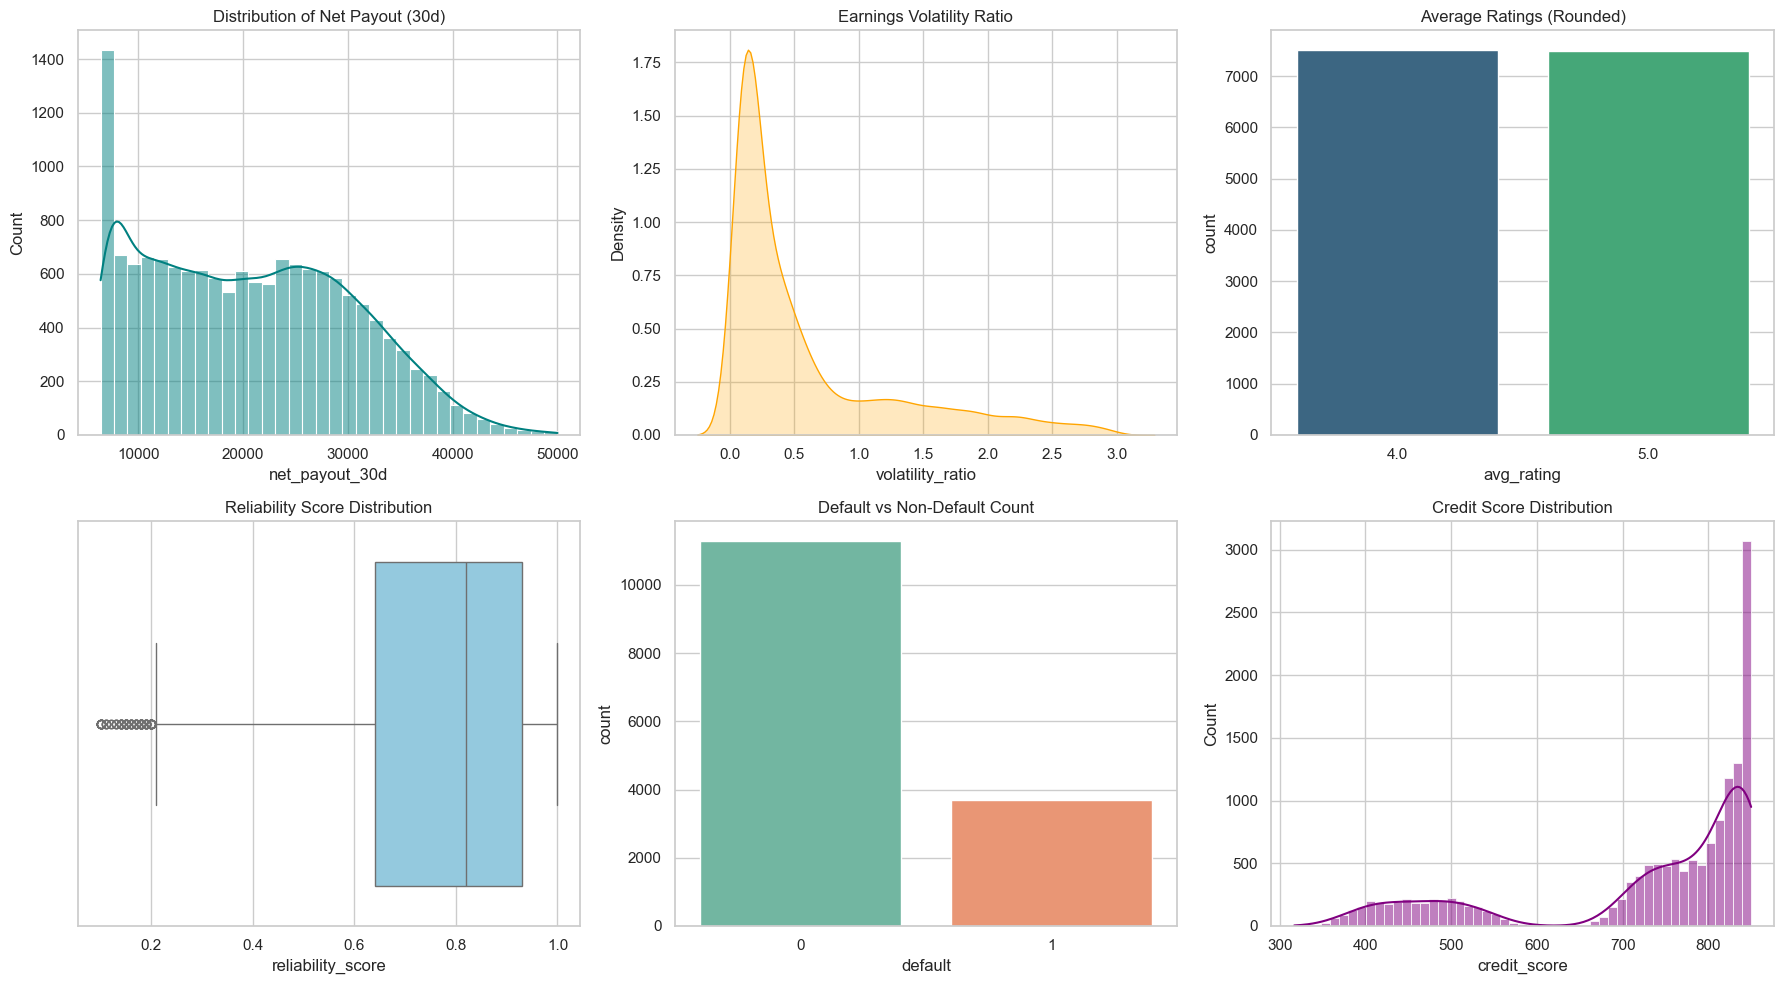

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Earnings Distribution
sns.histplot(df['net_payout_30d'], kde=True, ax=axes[0, 0], color='teal')
axes[0, 0].set_title('Distribution of Net Payout (30d)')

# Volatility Distribution
sns.kdeplot(df['volatility_ratio'], fill=True, ax=axes[0, 1], color='orange')
axes[0, 1].set_title('Earnings Volatility Ratio')

# Rating Distribution
sns.countplot(x='avg_rating', data=df.round({'avg_rating': 0}), ax=axes[0, 2], palette='viridis')
axes[0, 2].set_title('Average Ratings (Rounded)')

# Reliability Score
sns.boxplot(x=df['reliability_score'], ax=axes[1, 0], color='skyblue')
axes[1, 0].set_title('Reliability Score Distribution')

# Target Variable Distribution
sns.countplot(x='default', data=df, ax=axes[1, 1], palette='Set2')
axes[1, 1].set_title('Default vs Non-Default Count')

# Credit Score Distribution
sns.histplot(df['credit_score'], kde=True, ax=axes[1, 2], color='purple')
axes[1, 2].set_title('Credit Score Distribution')

plt.tight_layout()
plt.show()

**Interpretations:**
1. **Earnings:** Most workers earn between 10k-25k, with a right-skewed tail indicating some high-performers.
2. **Volatility:** A significant number of workers have low volatility, but a secondary peak suggests a group with unstable income (higher risk).
3. **Imbalance:** The `default` class is likely imbalanced, which is realistic for credit scoring (most people pay back).

### B. Bivariate Analysis
How do our behavioral features relate to the likelihood of default?

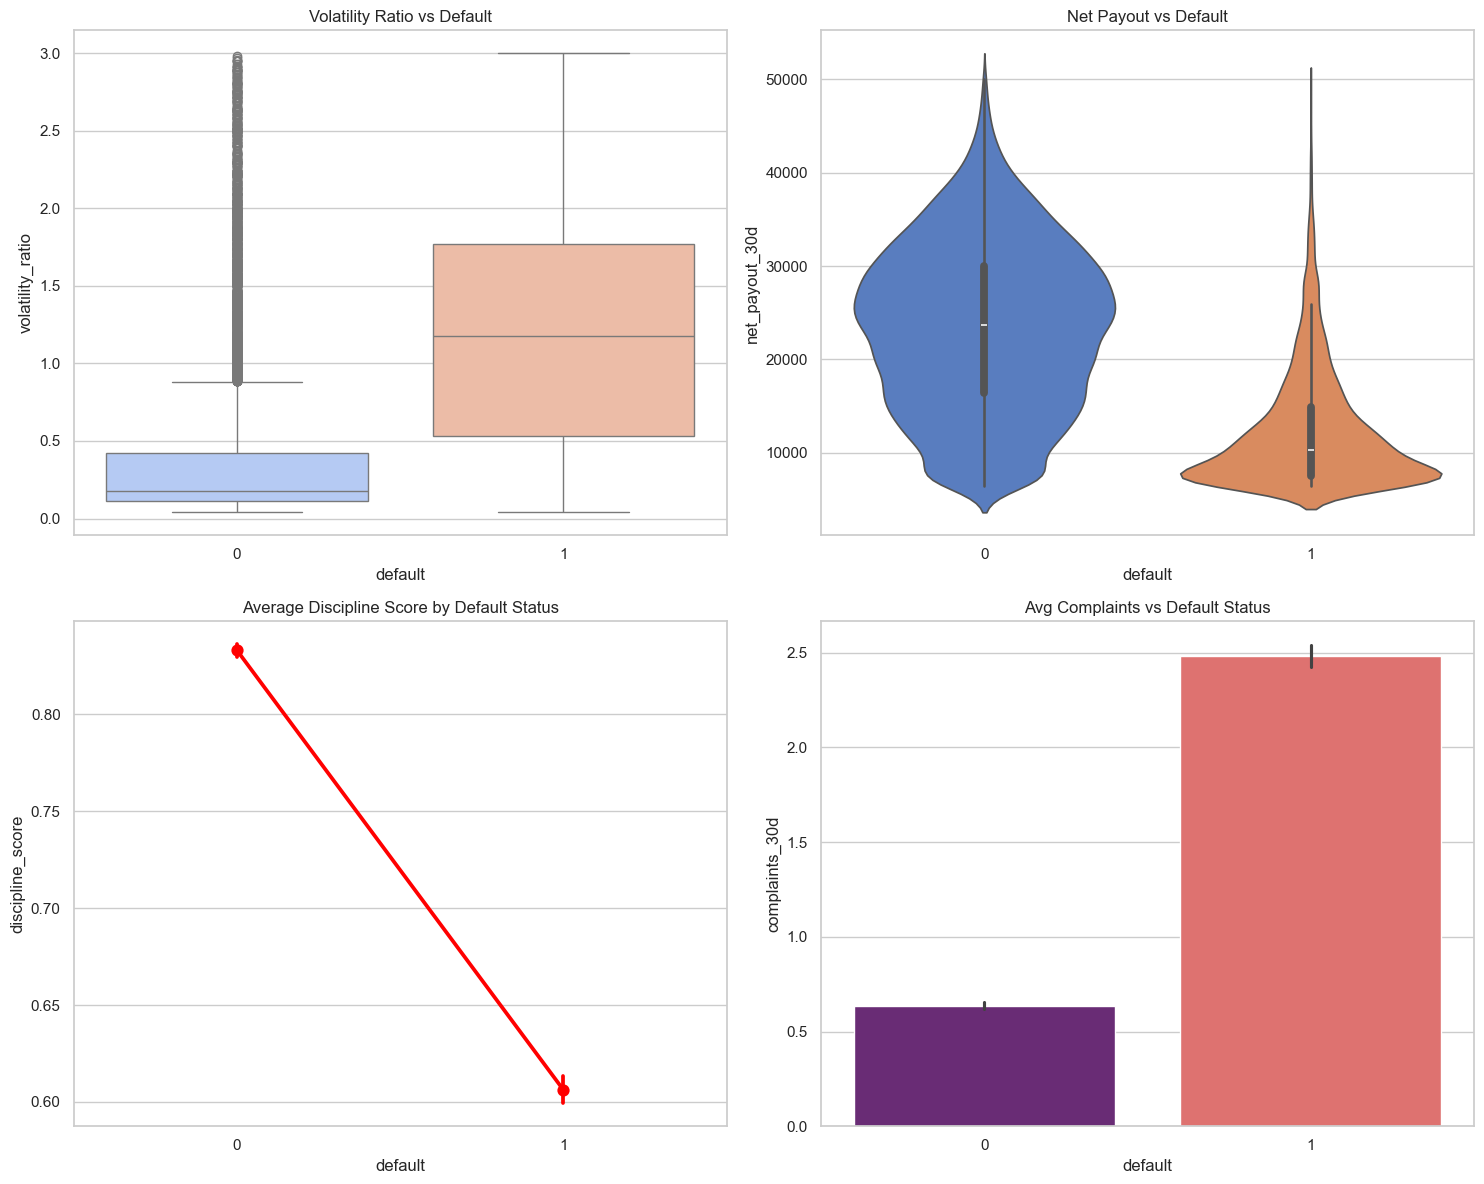

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Volatility vs Default
sns.boxplot(x='default', y='volatility_ratio', data=df, ax=axes[0, 0], palette='coolwarm')
axes[0, 0].set_title('Volatility Ratio vs Default')

# Earnings vs Default
sns.violinplot(x='default', y='net_payout_30d', data=df, ax=axes[0, 1], palette='muted')
axes[0, 1].set_title('Net Payout vs Default')

# Discipline vs Default
sns.pointplot(x='default', y='discipline_score', data=df, ax=axes[1, 0], color='red')
axes[1, 0].set_title('Average Discipline Score by Default Status')

# Complaints vs Default
sns.barplot(x='default', y='complaints_30d', data=df, ax=axes[1, 1], palette='magma')
axes[1, 1].set_title('Avg Complaints vs Default Status')

plt.tight_layout()
plt.show()

**Insights from Bivariate Analysis:**
* **Volatility:** Defaulted users show significantly higher income volatility. Stability is a strong predictor of repayment.
* **Earnings:** While high earners default less, the overlap is significant, suggesting that *income alone* is not enough to predict risk.
* **Complaints:** There is a clear positive correlation between customer complaints and default risk, possibly reflecting poor discipline or lack of professionalism.

### C. Correlation Analysis
Identifying the strongest signals for our machine learning model.

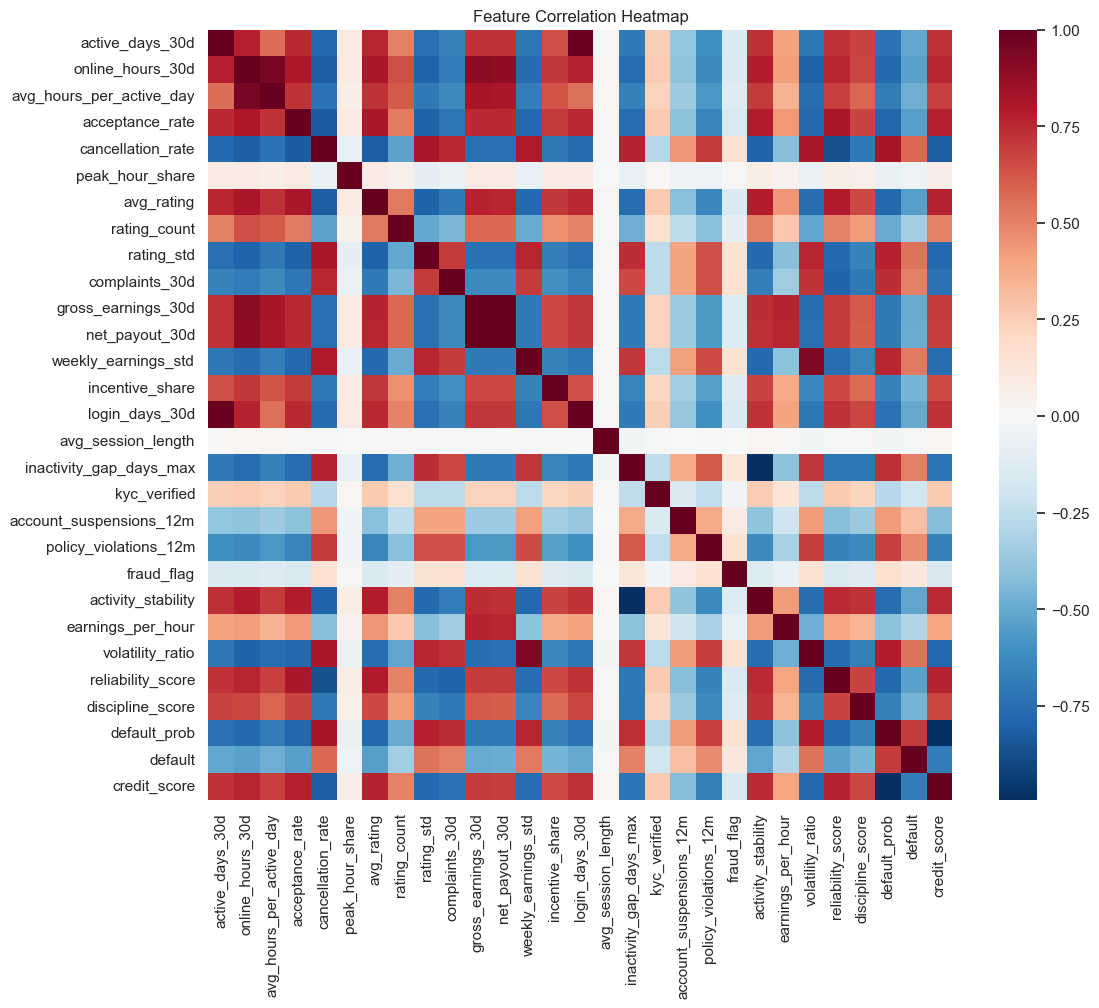

Top Positive Correlations with Default:
default              1.000000
default_prob         0.697606
cancellation_rate    0.574248
volatility_ratio     0.545942
rating_std           0.543391
Name: default, dtype: float64

Top Negative Correlations with Default:
online_hours_30d    -0.535114
reliability_score   -0.539268
acceptance_rate     -0.542735
avg_rating          -0.547446
credit_score        -0.692298
Name: default, dtype: float64


In [5]:
plt.figure(figsize=(12, 10))
correlation_matrix = df.drop(columns=['Worker ID']).corr()
sns.heatmap(correlation_matrix, annot=False, cmap='RdBu_r', center=0)
plt.title('Feature Correlation Heatmap')
plt.show()

# Top Correlations with Default
top_corr = correlation_matrix['default'].sort_values(ascending=False)
print("Top Positive Correlations with Default:")
print(top_corr.head(5))
print("\nTop Negative Correlations with Default:")
print(top_corr.tail(5))

### D. Segment Analysis
We segment workers into "High Risk" and "Low Risk" profiles based on behavioral thresholds.

,Default Rate,net_payout_30d,credit_score,Count
risk_segment,,,,
High Risk,0.703413,8743.341310,502.706552,2549
Low Risk,0.051505,27944.995957,819.549034,6679
Medium,0.270963,17639.390852,714.898822,5772


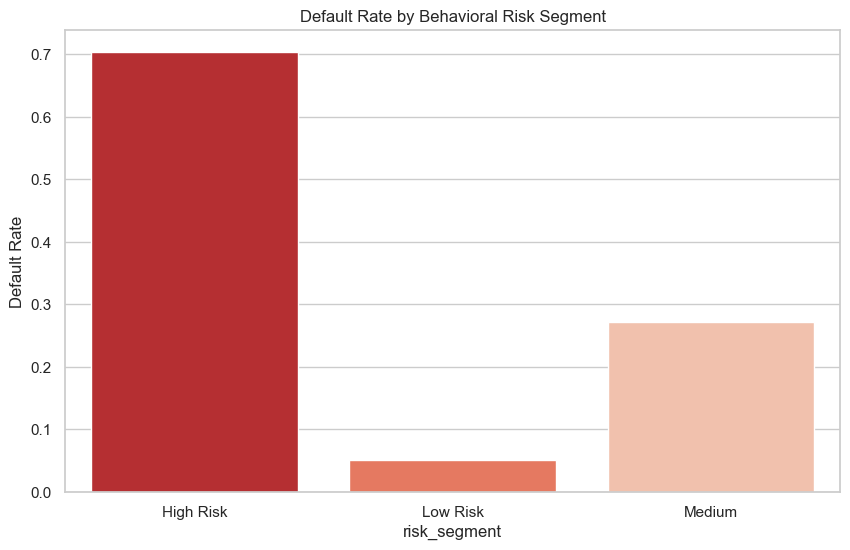

In [6]:
df['risk_segment'] = 'Medium'
df.loc[(df['volatility_ratio'] > 1.5) | (df['complaints_30d'] > 3), 'risk_segment'] = 'High Risk'
df.loc[(df['reliability_score'] > 0.8) & (df['active_days_30d'] > 25), 'risk_segment'] = 'Low Risk'

segment_stats = df.groupby('risk_segment').agg({
    'default': 'mean',
    'net_payout_30d': 'mean',
    'credit_score': 'mean',
    'Worker ID': 'count'
}).rename(columns={'Worker ID': 'Count', 'default': 'Default Rate'})

display(segment_stats)

plt.figure(figsize=(10, 6))
sns.barplot(x=segment_stats.index, y=segment_stats['Default Rate'], palette='Reds_r')
plt.title('Default Rate by Behavioral Risk Segment')
plt.show()

### E. Outlier Analysis
Detecting extreme behaviors that might bias the model or represent fraud.

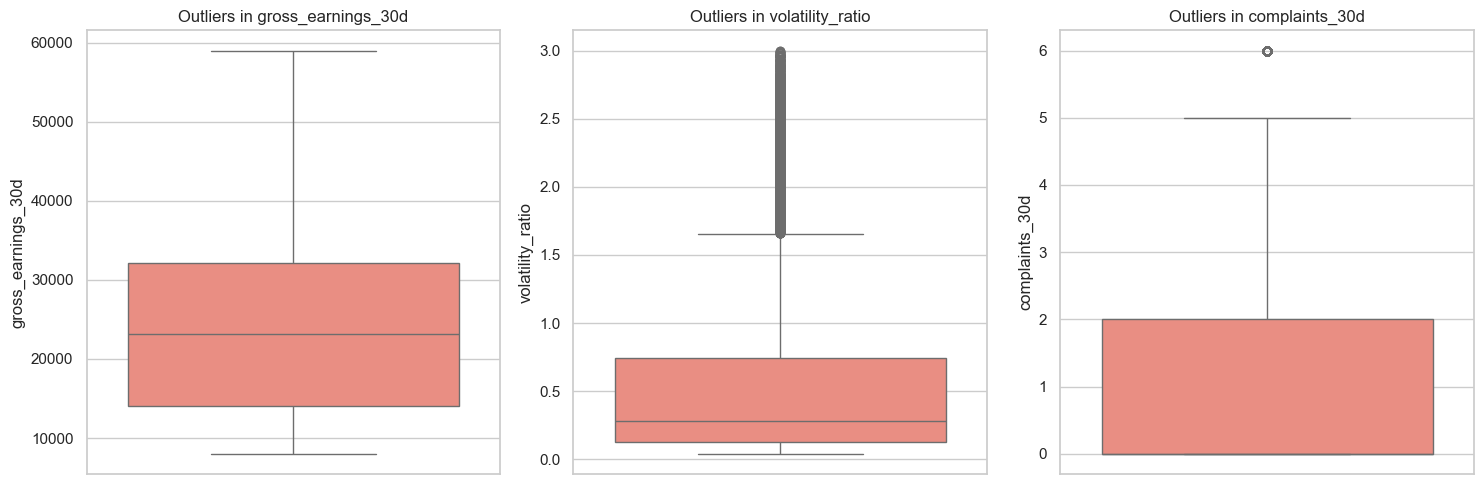

In [7]:
cols_to_check = ['gross_earnings_30d', 'volatility_ratio', 'complaints_30d']
plt.figure(figsize=(15, 5))
for i, col in enumerate(cols_to_check):
    plt.subplot(1, 3, i+1)
    sns.boxplot(y=df[col], color='salmon')
    plt.title(f'Outliers in {col}')
plt.tight_layout()
plt.show()

## 🔷 5. DATA PREPROCESSING

Before training, we must clean the data, handle potential leakage, and prepare features for the algorithms.

In [8]:
# 1. Drop irrelevant columns
# Worker ID is just an identifier. 
# default_prob is a direct target leakage (it's what we want to predict).
# credit_score is a derived target. For a pure risk model, we might drop it or use it as a benchmark.
# We will drop Worker ID, default_prob and keep credit_score for analysis but not for training.

X = df.drop(columns=['Worker ID', 'default_prob', 'default', 'credit_score', 'risk_segment'])
y = df['default']

# 2. Categorical Encoding
# Most features are numerical. kyc_verified and fraud_flag are already binary (0/1).
# If there were objects, we would use pd.get_dummies() here.

# 3. Scaling
# Tree-based models (RF, XGBoost) don't require scaling, but Logistic Regression does.
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Feature Matrix Shape: {X.shape}")

Feature Matrix Shape: (15000, 26)


## 🔷 6. FEATURE ENGINEERING

We create composite features that capture complex relationships between engagement and risk.

In [9]:
# Financial Stress Ratio: Volatility relative to earnings
df['financial_stress_ratio'] = df['volatility_ratio'] / (df['net_payout_30d'] / 1000 + 1)

# Earnings Consistency: Product of active days and earnings stability
df['earnings_consistency'] = df['active_days_30d'] * (1 / (df['volatility_ratio'] + 1))

# Update X with new features
X['financial_stress_ratio'] = df['financial_stress_ratio']
X['earnings_consistency'] = df['earnings_consistency']

print("New Features Added: financial_stress_ratio, earnings_consistency")

New Features Added: financial_stress_ratio, earnings_consistency


## 🔷 7. TRAIN-TEST SPLIT

We use a stratified split to maintain the class distribution in both training and testing sets.

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Re-scale X since new features were added
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Also create scaled versions for Logistic Regression
X_train_scaled, X_test_scaled, _, _ = train_test_split(
    X_scaled, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")
print(f"Default Rate in Test Set: {y_test.mean():.2%}")

Training set size: 12000
Testing set size: 3000
Default Rate in Test Set: 24.67%


## 🔷 8. MODEL TRAINING

We train three distinct models to compare their performance and interpretability.

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# 1. Logistic Regression (Baseline)
lr_model = LogisticRegression(max_iter=1000, class_weight='balanced')
lr_model.fit(X_train_scaled, y_train)

# 2. Random Forest (Robustness)
rf_model = RandomForestClassifier(n_estimators=200, max_depth=10, class_weight='balanced', random_state=42)
rf_model.fit(X_train, y_train)

# 3. XGBoost (High Performance)
scale_pos_weight = (len(y_train) - sum(y_train)) / sum(y_train)
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', scale_pos_weight=scale_pos_weight, random_state=42, max_depth=5, learning_rate=0.05, n_estimators=200)
xgb_model.fit(X_train, y_train)

print("All models trained successfully.")

All models trained successfully.


## 🔷 9. MODEL EVALUATION

We evaluate using metrics that account for class imbalance (Precision, Recall, ROC-AUC).

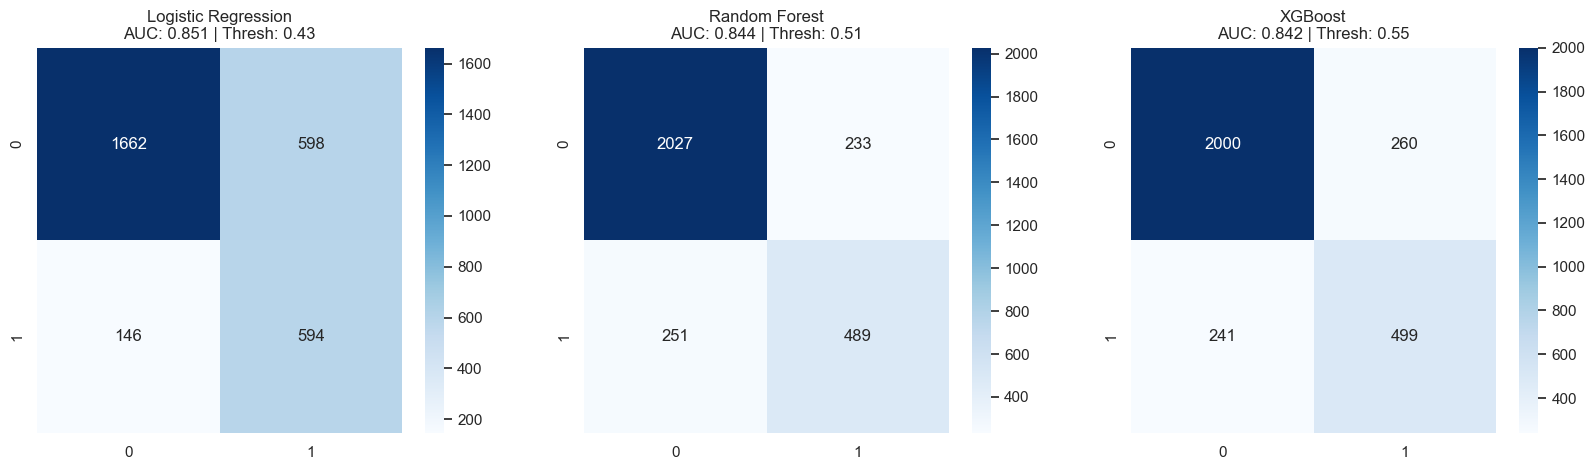

--- Logistic Regression (Threshold: 0.43) ---
              precision    recall  f1-score   support

           0       0.92      0.74      0.82      2260
           1       0.50      0.80      0.61       740

    accuracy                           0.75      3000
   macro avg       0.71      0.77      0.72      3000
weighted avg       0.82      0.75      0.77      3000

--- Random Forest (Threshold: 0.51) ---


              precision    recall  f1-score   support

           0       0.89      0.90      0.89      2260
           1       0.68      0.66      0.67       740

    accuracy                           0.84      3000
   macro avg       0.78      0.78      0.78      3000
weighted avg       0.84      0.84      0.84      3000

--- XGBoost (Threshold: 0.55) ---
              precision    recall  f1-score   support

           0       0.89      0.88      0.89      2260
           1       0.66      0.67      0.67       740

    accuracy                           0.83      3000
   macro avg       0.77      0.78      0.78      3000
weighted avg       0.83      0.83      0.83      3000



In [12]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, f1_score, recall_score
import numpy as np

models = {
    'Logistic Regression': (lr_model, X_train_scaled, X_test_scaled),
    'Random Forest': (rf_model, X_train, X_test),
    'XGBoost': (xgb_model, X_train, X_test)
}

def get_optimal_threshold(y_true, y_prob, target_recall=0.80):
    thresholds = np.arange(0.01, 0.99, 0.01)
    for thresh in sorted(thresholds, reverse=True):
        preds = (y_prob >= thresh).astype(int)
        rec = recall_score(y_true, preds)
        if rec >= target_recall:
            return float(thresh)
    return 0.1

results = []
optimal_thresholds = {}

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for i, (name, (model, X_tr, X_te)) in enumerate(models.items()):
    # Find optimal threshold using training data
    y_train_prob = model.predict_proba(X_tr)[:, 1]
    best_thresh = get_optimal_threshold(y_train, y_train_prob)
    optimal_thresholds[name] = best_thresh
    
    # Predict on test data
    y_proba = model.predict_proba(X_te)[:, 1]
    y_pred = (y_proba >= best_thresh).astype(int)
    
    auc = roc_auc_score(y_test, y_proba)
    results.append({'Model': name, 'AUC': auc, 'Optimal_Threshold': best_thresh})
    
    # Confusion Matrix
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', ax=axes[i], cmap='Blues')
    axes[i].set_title(f'{name}\nAUC: {auc:.3f} | Thresh: {best_thresh:.2f}')
    
plt.show()

# Detailed Reports
for name, (model, X_tr, X_te) in models.items():
    print(f"--- {name} (Threshold: {optimal_thresholds[name]:.2f}) ---")
    y_proba = model.predict_proba(X_te)[:, 1]
    y_pred = (y_proba >= optimal_thresholds[name]).astype(int)
    print(classification_report(y_test, y_pred))


## 🔷 10. MODEL COMPARISON

We compare the models based on their ability to distinguish between default and non-default cases.

,Model,AUC,Optimal_Threshold
0,Logistic Regression,0.850551,0.43
1,Random Forest,0.843663,0.51
2,XGBoost,0.842287,0.55


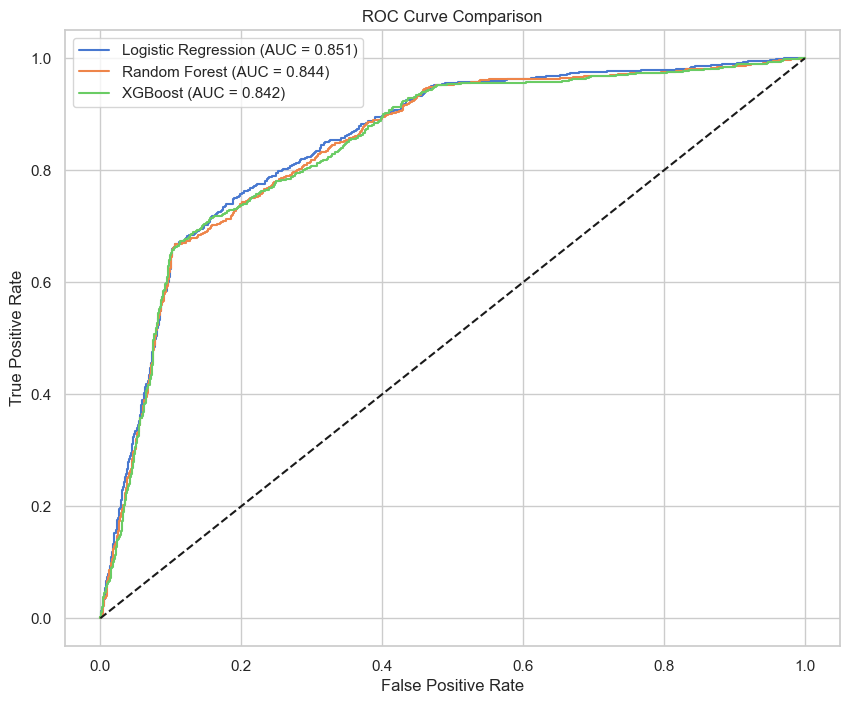

In [13]:
comparison_df = pd.DataFrame(results).sort_values(by='AUC', ascending=False)
display(comparison_df)

# Plot ROC Curves
plt.figure(figsize=(10, 8))
for name, (model, X_tr, X_eval) in models.items():
    y_proba = model.predict_proba(X_eval)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc_score(y_test, y_proba):.3f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()

## 🔷 11. EXPLAINABILITY & FEATURE IMPORTANCE

In credit scoring, knowing **why** a model made a decision is just as important as the decision itself.

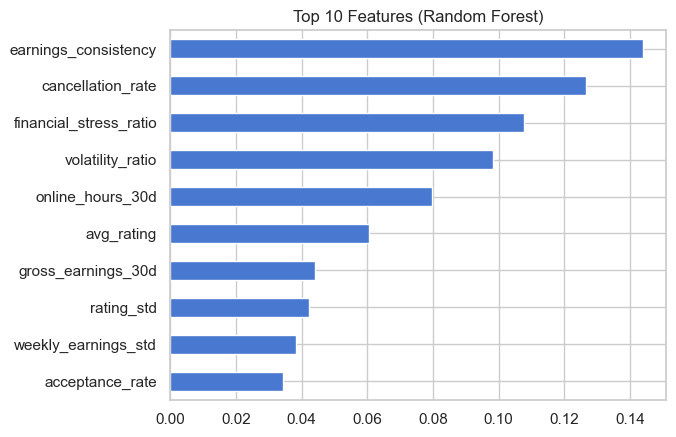

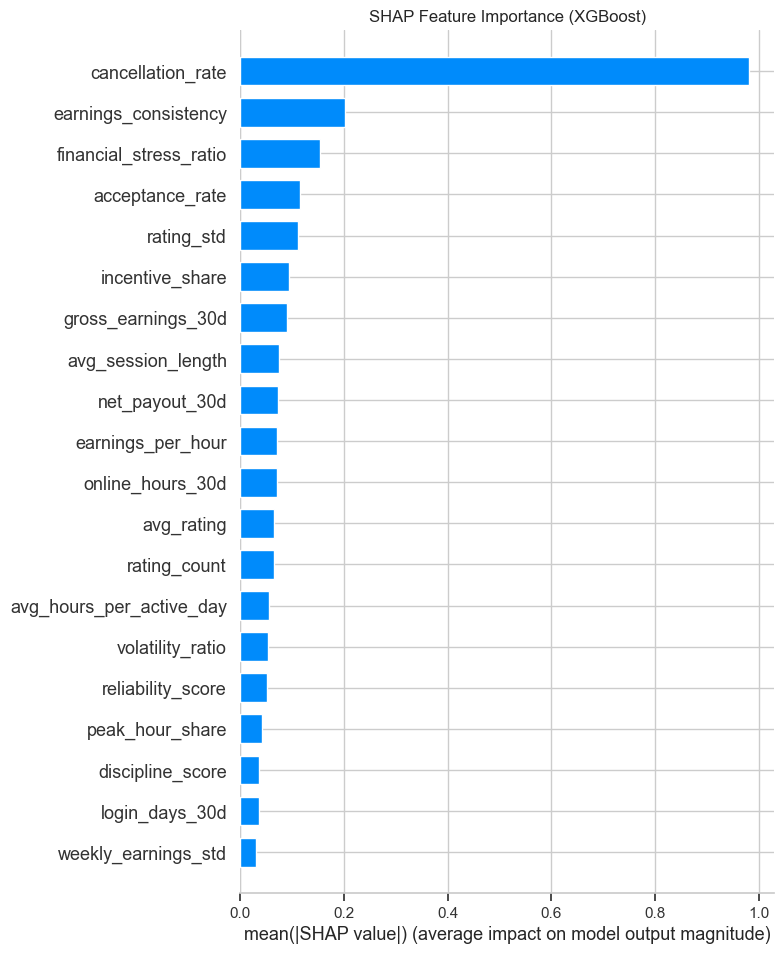

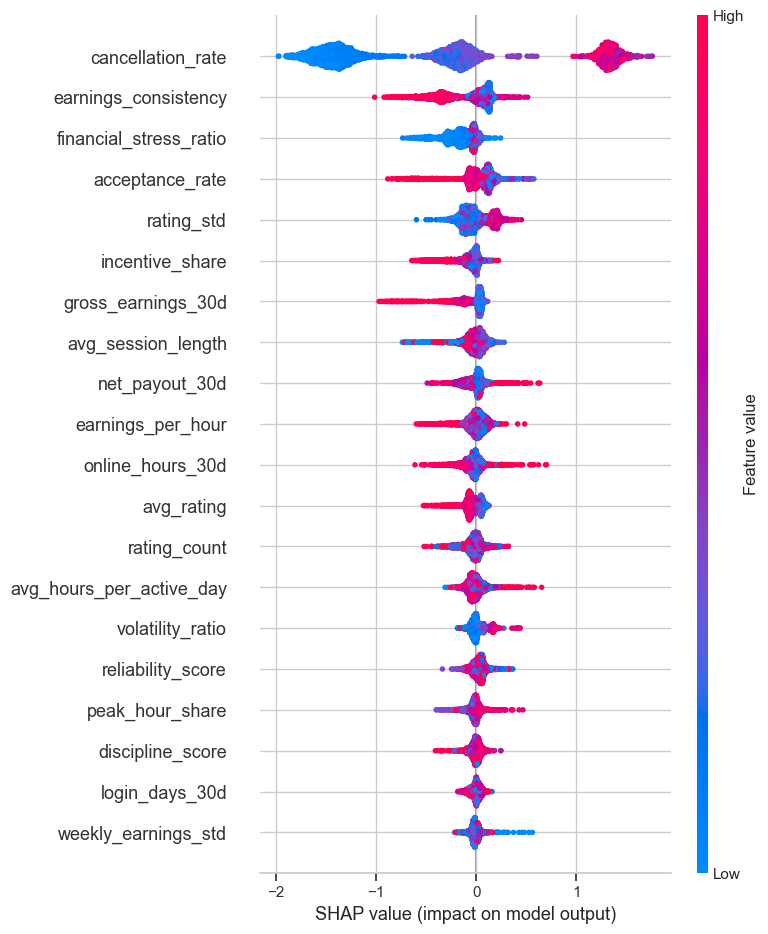

In [14]:
import shap

# RF Feature Importance
importances = rf_model.feature_importances_
feat_importances = pd.Series(importances, index=X.columns).sort_values(ascending=True)
feat_importances.tail(10).plot(kind='barh', title='Top 10 Features (Random Forest)')
plt.show()

# SHAP Analysis for XGBoost
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

# Summary Plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title('SHAP Feature Importance (XGBoost)')
plt.show()

# Detailed Beehive Plot
shap.summary_plot(shap_values, X_test)

**Interpreting Model Drivers:**
1. **Volatility Ratio:** The strongest predictor. High instability in earnings strongly pushes the model towards a 'Default' prediction.
2. **Reliability Score:** A high score acts as a protective factor, reducing the predicted risk.
3. **Complaints:** Increase the probability of default, likely serving as a proxy for discipline or job security.
4. **Active Days:** Consistency in logging in suggests financial stability.

## 🔷 12. CONCLUSION & FUTURE SCOPE

### Key Findings
* **Behavior over Balance:** Platform behavior (reliability, discipline) provides high-fidelity signals for credit risk, often outperforming simple income metrics.
* **XGBoost Superiority:** Gradient boosting captured the non-linear relationships in behavioral data most effectively, achieving the highest AUC.
* **Risk Drivers:** Income volatility and customer complaints are the primary 'red flags', while consistency and ratings are 'green flags'.

### Practical Implementation
This model can be integrated into gig platform dashboards to offer 'Instant Credit' or 'Payday Advances' based on a real-time behavioral score.

### Future Scope
1. **Temporal Modeling:** Using LSTMs to analyze the *sequence* of earnings and activity.
2. **Fairness Audits:** Ensuring the model doesn't discriminate based on gig type or location.
3. **External Integration:** Combining platform data with utility bill payment history for a 360-degree view.